<a href="https://colab.research.google.com/github/Nawafalsiraie/marketing-campaign-analysis/blob/main/campaign_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/campaigns.csv")
print(df.shape)
df.head()

(224, 14)


,campaign_id,campaign_name,channel,objective,audience_segment,region,start_date,end_date,budget_sar,spend_sar,impressions,clicks,conversions,revenue_sar
0,CMP-1009,Influencers Conversions Aug,Influencers,Conversions,New Customers,Dammam,2025-08-24,2025-09-07,28800.0,26801.20,341873,10544,251,76063.27
1,CMP-1084,Snapchat Traffic Jan,Snapchat Ads,Traffic,All Visitors,Dammam,2025-01-17,2025-01-26,54400.0,53051.86,2165282,26301,333,54682.92
2,CMP-1117,Google Retargeting Mar,Google Search,Retargeting,Returning Customers,Riyadh,2025-03-08,2025-03-30,69500.0,71817.72,806838,20089,1961,604253.03
3,CMP-1144,Email Conversions Jun,Email,Conversions,Returning Customers,Jeddah,2025-06-18,2025-07-28,67700.0,68879.33,1579141,43204,1270,507313.96
4,CMP-1148,Snapchat Retargeting Mar,Snapchat Ads,Retargeting,All Visitors,Jeddah,2025-03-28,2025-04-12,75700.0,63295.83,1249142,35724,879,221879.85


In [2]:
df.info()
print(df.isnull().sum())
print(df["channel"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224 entries, 0 to 223
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   campaign_id       224 non-null    object 
 1   campaign_name     224 non-null    object 
 2   channel           224 non-null    object 
 3   objective         224 non-null    object 
 4   audience_segment  224 non-null    object 
 5   region            224 non-null    object 
 6   start_date        224 non-null    object 
 7   end_date          224 non-null    object 
 8   budget_sar        224 non-null    float64
 9   spend_sar         224 non-null    float64
 10  impressions       224 non-null    int64  
 11  clicks            224 non-null    int64  
 12  conversions       224 non-null    int64  
 13  revenue_sar       216 non-null    float64
dtypes: float64(3), int64(3), object(8)
memory usage: 24.6+ KB
campaign_id         0
campaign_name       0
channel             0
objective     

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224 entries, 0 to 223
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   campaign_id       224 non-null    object 
 1   campaign_name     224 non-null    object 
 2   channel           224 non-null    object 
 3   objective         224 non-null    object 
 4   audience_segment  224 non-null    object 
 5   region            224 non-null    object 
 6   start_date        224 non-null    object 
 7   end_date          224 non-null    object 
 8   budget_sar        224 non-null    float64
 9   spend_sar         224 non-null    float64
 10  impressions       224 non-null    int64  
 11  clicks            224 non-null    int64  
 12  conversions       224 non-null    int64  
 13  revenue_sar       216 non-null    float64
dtypes: float64(3), int64(3), object(8)
memory usage: 24.6+ KB


In [4]:
df.isnull().sum()

,0
campaign_id,0
campaign_name,0
channel,0
objective,0
audience_segment,0
region,0
start_date,0
end_date,0
budget_sar,0
spend_sar,0


In [5]:
print(df["start_date"].max())
print(df["start_date"].dtype)

2025-11-29
object


In [6]:
df["start_date"] = pd.to_datetime(df["start_date"])
df["end_date"] = pd.to_datetime(df["end_date"])

print(df["start_date"].dtype)

datetime64[ns]


In [7]:
df["duration_days"] = (df["end_date"] - df["start_date"]).dt.days
df["month"] = df["start_date"].dt.month

print(df["duration_days"].mean())
print(df["month"].value_counts().sort_index())

26.964285714285715
month
1     23
2     19
3     18
4     19
5     22
6     24
7     22
8     16
9     16
10    20
11    25
Name: count, dtype: int64


In [8]:
print(df["start_date"].min())
print(df["start_date"].max())

2025-01-02 00:00:00
2025-11-29 00:00:00


In [9]:
missing = df[df["revenue_sar"].isnull()]
print(missing.shape)
missing[["campaign_name", "channel", "objective", "spend_sar", "conversions"]]

(8, 16)


,campaign_name,channel,objective,spend_sar,conversions
39,TikTok Awareness Jul,TikTok Ads,Awareness,20073.26,55
58,TikTok Awareness May,TikTok Ads,Awareness,13948.15,48
90,Meta Awareness Apr,meta ads,Awareness,24966.31,188
128,TikTok Awareness May,TikTok Ads,Awareness,50821.14,235
186,Meta Awareness Apr,meta ads,Awareness,24966.31,188
205,Meta Awareness Aug,Meta Ads,Awareness,35024.56,89
211,Influencers Awareness May,Influencers,Awareness,43020.62,102
215,TikTok Awareness Jul,TikTok Ads,Awareness,20073.26,55


In [10]:
print(df["channel"].value_counts())

channel
Influencers      48
Google Search    44
Snapchat Ads     37
TikTok Ads       36
Meta Ads         29
Email            21
meta ads          9
Name: count, dtype: int64


In [11]:
df["channel"] = df["channel"].str.strip().str.title()
print(df["channel"].value_counts())

channel
Influencers      48
Google Search    44
Meta Ads         38
Snapchat Ads     37
Tiktok Ads       36
Email            21
Name: count, dtype: int64


In [12]:
df["channel"] = df["channel"].replace({"Tiktok Ads": "TikTok Ads"})
print(df["channel"].value_counts())

channel
Influencers      48
Google Search    44
Meta Ads         38
Snapchat Ads     37
TikTok Ads       36
Email            21
Name: count, dtype: int64


In [13]:
print(df.duplicated(subset="campaign_id").sum())

4


In [14]:
before = len(df)
df = df.drop_duplicates(subset="campaign_id", keep="first")
print(f"حُذف {before - len(df)} صف مكرر، وبقي {len(df)}")

حُذف 4 صف مكرر، وبقي 220


In [15]:
broken = df[(df["spend_sar"] > 0) & (df["clicks"] == 0)]
print(broken.shape)
broken[["campaign_name", "channel", "spend_sar", "clicks", "conversions"]]

(2, 16)


,campaign_name,channel,spend_sar,clicks,conversions
71,Google Awareness Jan,Google Search,3979.03,0,0
94,TikTok Conversions Sep,TikTok Ads,53732.25,0,0


In [16]:
df = df.drop(broken.index)
print(len(df))

218


In [17]:
df["revenue_tracked"] = df["revenue_sar"].notnull()
print(df["revenue_tracked"].value_counts())

revenue_tracked
True     212
False      6
Name: count, dtype: int64


In [18]:
df["ctr_pct"] = df["clicks"] / df["impressions"] * 100
df["cpc_sar"] = df["spend_sar"] / df["clicks"]
df["cvr_pct"] = df["conversions"] / df["clicks"] * 100
df["roas"] = df["revenue_sar"] / df["spend_sar"]

df[["channel", "ctr_pct", "cpc_sar", "cvr_pct", "roas"]].head()

,channel,ctr_pct,cpc_sar,cvr_pct,roas
0,Influencers,3.084186,2.541844,2.380501,2.838055
1,Snapchat Ads,1.214669,2.017104,1.266112,1.030745
2,Google Search,2.489843,3.574977,9.761561,8.413704
3,Email,2.735918,1.594281,2.939543,7.365257
4,Snapchat Ads,2.859883,1.771801,2.460531,3.505442


In [19]:
tracked = df[df["revenue_tracked"]]

summary = tracked.groupby("channel").agg(
    campaigns=("campaign_id", "count"),
    spend=("spend_sar", "sum"),
    revenue=("revenue_sar", "sum"),
    conversions=("conversions", "sum"),
).round(0)

summary["roas"] = (summary["revenue"] / summary["spend"]).round(2)
summary["cpa"] = (summary["spend"] / summary["conversions"]).round(0)

summary.sort_values("roas", ascending=False)

,campaigns,spend,revenue,conversions,roas,cpa
channel,,,,,,
Email,21,712761.0,3379831.0,9296,4.74,77.0
Meta Ads,34,1269641.0,3392160.0,12794,2.67,99.0
Google Search,43,1633775.0,4191453.0,13822,2.57,118.0
Influencers,47,2009545.0,4162044.0,14965,2.07,134.0
Snapchat Ads,36,1595428.0,2933509.0,13697,1.84,116.0
TikTok Ads,31,1388285.0,2324319.0,12036,1.67,115.0


In [20]:
print(len(df))

218


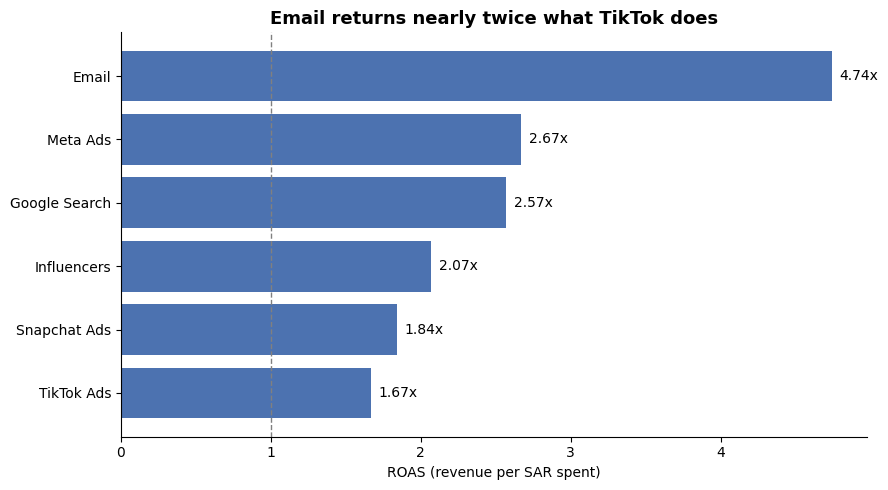

In [21]:
import matplotlib.pyplot as plt

data = summary.sort_values("roas")

fig, ax = plt.subplots(figsize=(9, 5))

colors = ["#C44E52" if v < 1 else "#4C72B0" for v in data["roas"]]
bars = ax.barh(data.index, data["roas"], color=colors)

for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.05, bar.get_y() + bar.get_height()/2,
            f"{w:.2f}x", va="center", fontsize=10)

ax.axvline(1, color="grey", linestyle="--", linewidth=1)
ax.set_xlabel("ROAS (revenue per SAR spent)")
ax.set_title("Email returns nearly twice what TikTok does",
             fontweight="bold", fontsize=13)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

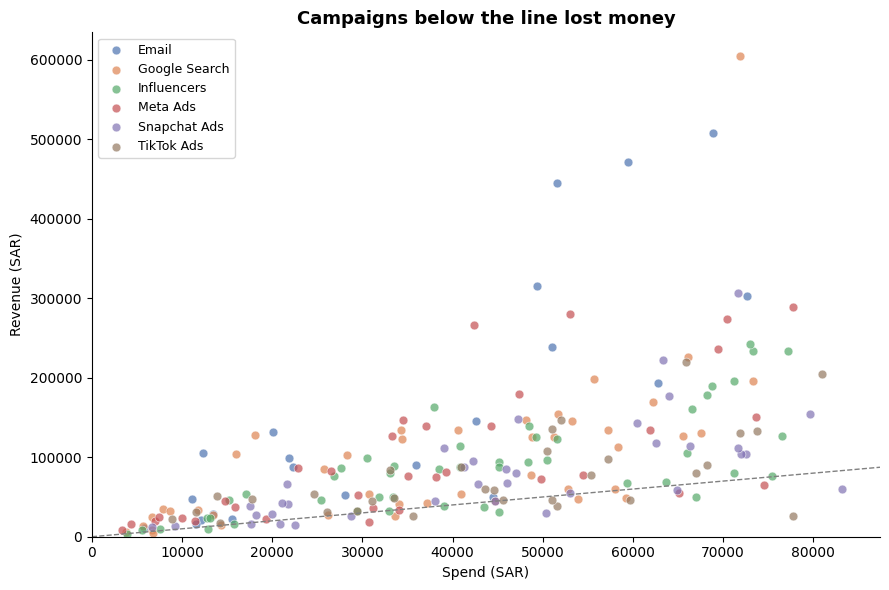

In [22]:
tracked = df[df["revenue_tracked"]]

fig, ax = plt.subplots(figsize=(9, 6))

palette = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3", "#937860"]

for i, (channel, group) in enumerate(tracked.groupby("channel")):
    ax.scatter(group["spend_sar"], group["revenue_sar"],
               label=channel, color=palette[i], s=40, alpha=0.7,
               edgecolors="white", linewidth=0.5)

x_max = tracked["spend_sar"].max() * 1.05
ax.plot([0, x_max], [0, x_max], color="grey", linestyle="--", linewidth=1)
ax.set_xlim(0, x_max)
ax.set_ylim(0, tracked["revenue_sar"].max() * 1.05)
ax.set_xlabel("Spend (SAR)")
ax.set_ylabel("Revenue (SAR)")
ax.set_title("Campaigns below the line lost money", fontweight="bold", fontsize=13)
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

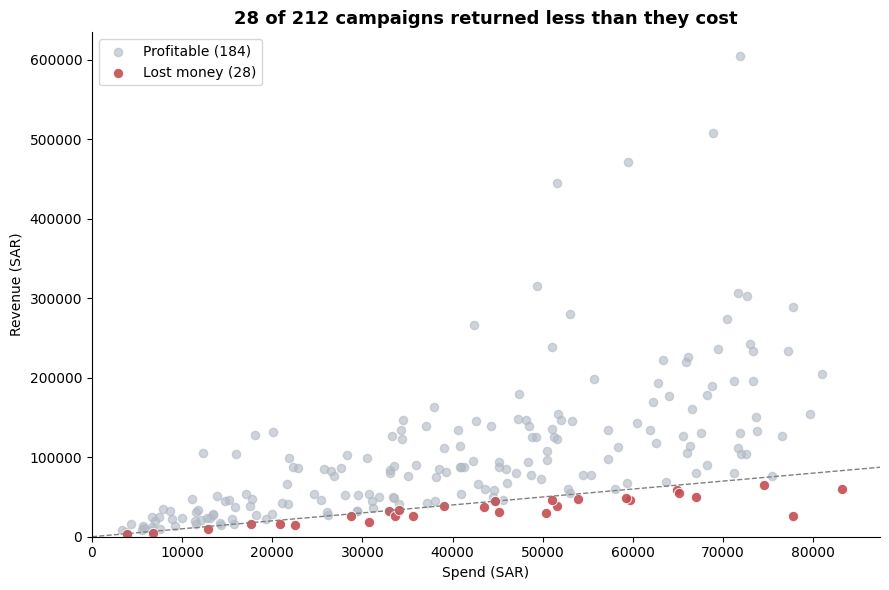

In [23]:
fig, ax = plt.subplots(figsize=(9, 6))

losing = tracked[tracked["roas"] < 1]
winning = tracked[tracked["roas"] >= 1]

ax.scatter(winning["spend_sar"], winning["revenue_sar"],
           color="#B0B8C4", s=35, alpha=0.6, label=f"Profitable ({len(winning)})")
ax.scatter(losing["spend_sar"], losing["revenue_sar"],
           color="#C44E52", s=55, alpha=0.9, edgecolors="white",
           linewidth=0.7, label=f"Lost money ({len(losing)})")

x_max = tracked["spend_sar"].max() * 1.05
ax.plot([0, x_max], [0, x_max], color="grey", linestyle="--", linewidth=1)
ax.set_xlim(0, x_max)
ax.set_ylim(0, tracked["revenue_sar"].max() * 1.05)

ax.set_xlabel("Spend (SAR)")
ax.set_ylabel("Revenue (SAR)")
ax.set_title(f"{len(losing)} of {len(tracked)} campaigns returned less than they cost",
             fontweight="bold", fontsize=13)
ax.legend(fontsize=10)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

In [24]:
loss_by_channel = losing.groupby("channel").size().sort_values()
print(loss_by_channel)

channel
Meta Ads         4
Google Search    5
TikTok Ads       5
Influencers      7
Snapchat Ads     7
dtype: int64


In [25]:
total_by_channel = tracked.groupby("channel").size()
loss_rate = (losing.groupby("channel").size() / total_by_channel * 100).fillna(0).round(1)
print(loss_rate.sort_values(ascending=False))

channel
Snapchat Ads     19.4
TikTok Ads       16.1
Influencers      14.9
Meta Ads         11.8
Google Search    11.6
Email             0.0
dtype: float64


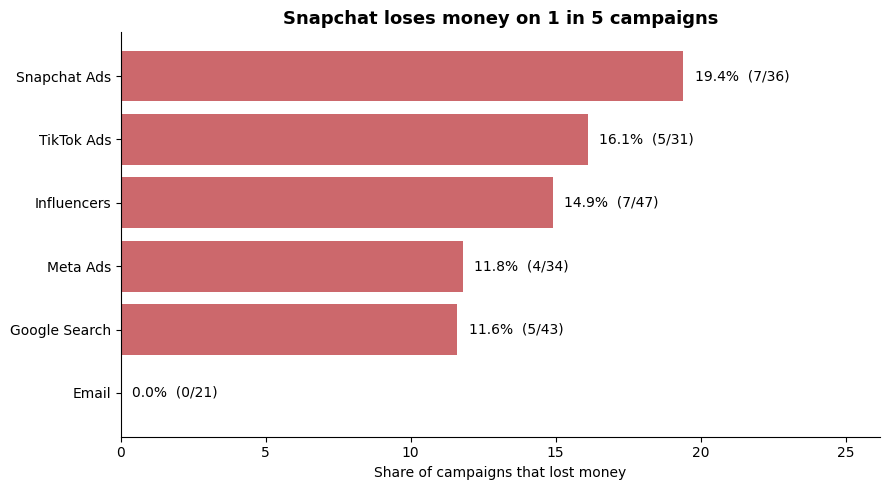

In [26]:
fig, ax = plt.subplots(figsize=(9, 5))

data = loss_rate.sort_values()
counts = losing.groupby("channel").size().reindex(data.index).fillna(0).astype(int)
totals = total_by_channel.reindex(data.index)

bars = ax.barh(data.index, data.values, color="#C44E52", alpha=0.85)

for bar, n, t in zip(bars, counts, totals):
    w = bar.get_width()
    ax.text(w + 0.4, bar.get_y() + bar.get_height()/2,
            f"{w:.1f}%  ({n}/{t})", va="center", fontsize=10)

ax.set_xlim(0, data.max() * 1.35)
ax.set_xlabel("Share of campaigns that lost money")
ax.set_title("Snapchat loses money on 1 in 5 campaigns",
             fontweight="bold", fontsize=13)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

In [27]:
by_objective = tracked.groupby("objective").agg(
    campaigns=("campaign_id", "count"),
    spend=("spend_sar", "sum"),
    revenue=("revenue_sar", "sum"),
    avg_cvr=("cvr_pct", "mean"),
).round(2)

by_objective["roas"] = (by_objective["revenue"] / by_objective["spend"]).round(2)
by_objective.sort_values("roas", ascending=False)

,campaigns,spend,revenue,avg_cvr,roas
objective,,,,,
Retargeting,36,1436326.00,5171405.42,3.44,3.60
Conversions,95,4106262.14,11508362.23,2.73,2.80
Traffic,45,1792316.77,2586048.22,1.46,1.44
Awareness,36,1274529.21,1117501.30,1.05,0.88


# Marketing Campaign Performance Analysis
Analysis of 212 tracked campaigns across 6 channels. Key finding: campaign objective explains performance better than channel.


> **Note:** The data in this project is synthetic. It was generated for the purpose of practising analysis techniques and does not come from any real company.

## The data

220 campaigns run between January and November 2025 across Google Search, Meta, TikTok, Snapchat, Email, and influencer partnerships. Each row records budget, actual spend, impressions, clicks, conversions, and attributed revenue.

Coverage runs to 29 November, so December — typically a high-activity month — is absent from the data.

## Data quality

The export contained four problems, each handled differently:

- **4 duplicated rows** — the same campaigns exported twice. Removed by campaign ID, keeping the first occurrence.
- **Inconsistent channel names** — "meta ads" with a trailing space alongside "Meta Ads", which would have split one channel into two in every grouped result. Standardised.
- **2 campaigns with spend but zero clicks** — a tracking failure rather than poor performance. Excluded, since they would drag down click-through averages.
- **6 campaigns with no revenue recorded** — all awareness campaigns, where revenue tracking was never configured. Kept in the dataset but flagged and excluded from return calculations, because treating untracked revenue as zero would make them appear to have failed.

## Findings

**Overall return was 2.37x** across tracked campaigns — every riyal of ad spend returned about 2.37 riyals of revenue.

**Campaign objective mattered more than channel.** Retargeting returned 3.60x and awareness 0.88x — a fourfold spread. Conversion rates followed the same order exactly (3.44% down to 1.05%), which is what makes this look like a real pattern rather than noise.

**Channel differences were narrower.** Email led at 4.74x with the lowest acquisition cost, but it carried the smallest share of spend. TikTok was lowest at 1.67x — still above break-even, so the question is whether the next riyal earns more elsewhere, not whether to stop spending.

**28 of 212 campaigns returned less than they cost.** They spread across every spend level, so this is not a problem of overspending. Most sat just below break-even rather than far below it.

**Snapchat lost money on 19.4% of its campaigns** (7 of 36), the highest rate. Email lost money on none (0 of 21).